# Apply Patnaik-Pearson to BERT layers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd
import random

import torch

from transformers import BertModel, BertTokenizer

C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260527\PatnaikPearson\ml_env311_v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
N = 512         # number of random tokens to sample
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE = ", DEVICE)

DEVICE =  cuda


In [4]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_hidden_states=True,
    attn_implementation="eager"
).to(DEVICE)

model.eval()

C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260527\PatnaikPearson\ml_env311_v2\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A par

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [5]:
print(type(model))
print(type(tokenizer))

<class 'transformers.models.bert.modeling_bert.BertModel'>
<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>


# Run the experiment

In [7]:
num_iterations = 5 #100

xx = pp.bert_token_embedding_layerwise_pp_dim_experiment(model, tokenizer, DEVICE = DEVICE, N = 512, num_iterations = num_iterations)

vocab_size =  29528
iteration 0
np_random_token_ids : max =  30510.0 , min =  1211.0 , mean =  15858.3984375 , std =  8451.30290236349
iteration 1
np_random_token_ids : max =  30493.0 , min =  1048.0 , mean =  15957.17578125 , std =  8525.489312636677
iteration 2
np_random_token_ids : max =  30465.0 , min =  1032.0 , mean =  15538.7421875 , std =  8574.613638340445
iteration 3
np_random_token_ids : max =  30467.0 , min =  1038.0 , mean =  16034.705078125 , std =  8690.111317799989
iteration 4
np_random_token_ids : max =  30518.0 , min =  1128.0 , mean =  16768.712890625 , std =  8286.136438635172


In [8]:
# convert to a single dataframe

# create an empty dataframe
df = pd.DataFrame({
'value_type': [],
'layer_index': [],
'values': []
})

for this_key in xx:
    print(this_key)
    xx1 = xx[this_key]
    print(type(xx1))
    for layer_idx in xx1:
        xx2 = xx1[layer_idx]
        for yy in xx2:
            df.loc[len(df)] = [this_key, layer_idx, yy]

print(df.shape)
print(df.head(5))
print(df.tail(5))

# export to csv
file_name = 'pp_bert_layers.csv'
#df.to_csv(file_name, index=False)

layer_pp_dim
<class 'dict'>
layer_nu_over_d
<class 'dict'>
layer_nu_over_N
<class 'dict'>
(195, 3)
     value_type  layer_index      values
0  layer_pp_dim            0  386.497345
1  layer_pp_dim            0  386.743988
2  layer_pp_dim            0  387.184204
3  layer_pp_dim            0  386.951935
4  layer_pp_dim            0  386.230927
          value_type  layer_index    values
190  layer_nu_over_N           12  0.233357
191  layer_nu_over_N           12  0.219173
192  layer_nu_over_N           12  0.245378
193  layer_nu_over_N           12  0.224431
194  layer_nu_over_N           12  0.225098


In [12]:
# Read CSV file into DataFrame
df = pd.read_csv(file_name)

print(df.shape)
print(df.head(5))
print(df.tail(5))

(3900, 3)
     value_type  layer_index      values
0  layer_pp_dim            0  386.470276
1  layer_pp_dim            0  386.054474
2  layer_pp_dim            0  385.552368
3  layer_pp_dim            0  386.179169
4  layer_pp_dim            0  386.205292
           value_type  layer_index    values
3895  layer_nu_over_N           12  0.197135
3896  layer_nu_over_N           12  0.227507
3897  layer_nu_over_N           12  0.209336
3898  layer_nu_over_N           12  0.218982
3899  layer_nu_over_N           12  0.223465


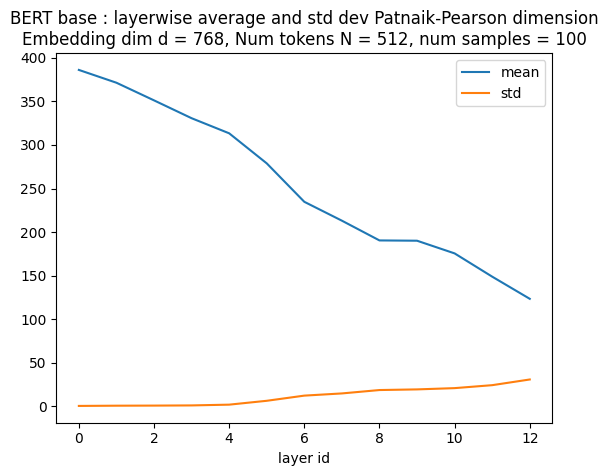

In [13]:
layer_pp_dim_title = "BERT base : layerwise average and std dev Patnaik-Pearson dimension\n"
layer_pp_dim_title += "Embedding dim d = 768, Num tokens N = 512, num samples = 100"

layer_pp_dim_image_name = "test.pdf" # "bert_base_layer_pp_dim.pdf"

pp.plot_per_layer_graphs(df, num_layers = 13,
                          this_key = 'layer_pp_dim', 
                          this_title = layer_pp_dim_title, 
                          this_image_name  = layer_pp_dim_image_name)

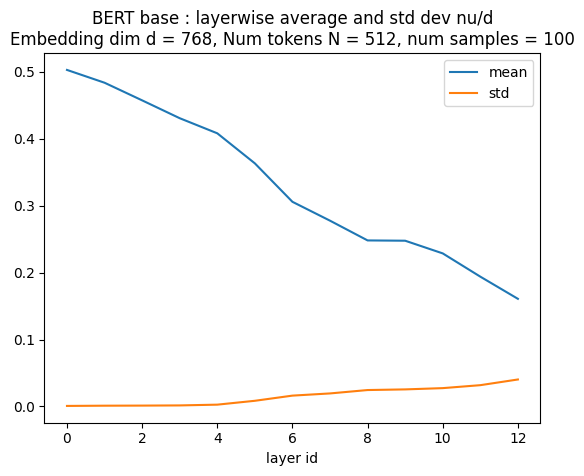

In [15]:
layer_nu_over_d_title = "BERT base : layerwise average and std dev nu/d\n"
layer_nu_over_d_title += "Embedding dim d = 768, Num tokens N = 512, num samples = 100"

layer_nu_over_d_image_name = "test.pdf" # "bert_base_layer_nu_over_d.pdf"

pp.plot_per_layer_graphs(df, num_layers = 13,
                          this_key = 'layer_nu_over_d', 
                          this_title = layer_nu_over_d_title, 
                          this_image_name  = layer_nu_over_d_image_name)

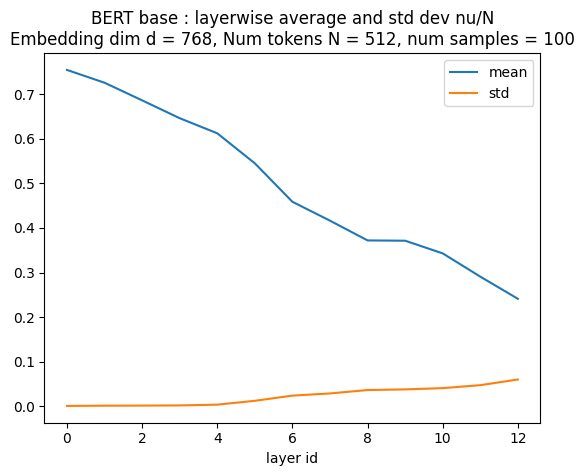

In [17]:
layer_nu_over_N_title = "BERT base : layerwise average and std dev nu/N\n"
layer_nu_over_N_title += "Embedding dim d = 768, Num tokens N = 512, num samples = 100"

layer_nu_over_N_image_name = "test.pdf" #"bert_base_layer_nu_over_N.pdf"

pp.plot_per_layer_graphs(df, num_layers = 13,
                          this_key = 'layer_nu_over_N', 
                          this_title = layer_nu_over_N_title, 
                          this_image_name  = layer_nu_over_N_image_name)

# ** OLD AND SPARE **

In [ ]:
valid_bert_base_token_ids = pp.get_valid_bert_base_token_ids()
vocab_size = len(valid_bert_base_token_ids)

random_indices = np.random.choice(vocab_size, N, replace = False)
print(type(random_indices))
print(len(random_indices))

np_random_token_ids = np.zeros(len(random_indices))
count = 0
for i in random_indices:
    np_random_token_ids[count] = valid_bert_base_token_ids[i]
    count+=1
    
random_token_ids = torch.tensor(np_random_token_ids, dtype=torch.long)
#random_token_ids = torch.randint(0, vocab_size, (N,), dtype=torch.long)
print(type(random_token_ids))
print(random_token_ids.shape)
#print(random_token_ids)

In [ ]:
k = 10
print("Sampled token IDs:", random_token_ids.tolist()[0:k])
print("Sampled tokens:   ", tokenizer.convert_ids_to_tokens(random_token_ids.tolist())[0:k])

In [ ]:
# ── Build input: shape (1, N) — single "sentence" of N tokens ───────────────
input_ids      = random_token_ids.unsqueeze(0).to(DEVICE)          # (1, N)
attention_mask = torch.ones(1, N, dtype=torch.long).to(DEVICE)     # no padding

In [ ]:
print(type(input_ids))
print(input_ids.shape)

In [ ]:
# ── Forward pass ─────────────────────────────────────────────────────────────
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

In [ ]:
# ── Extract per-layer representations ────────────────────────────────────────
# hidden_states is a tuple of (num_layers + 1) tensors, each shape (1, N, 768)
# Index 0 = embedding layer, indices 1–12 = transformer layers 1–12
hidden_states = outputs.hidden_states  # tuple of 13 tensors

In [ ]:
print(type(hidden_states))
print(len(hidden_states))
for xx in hidden_states:
    print(type(xx), xx.shape)

In [ ]:
layer_representations = {}
for layer_idx, hs in enumerate(hidden_states):
    layer_representations[layer_idx] = hs.squeeze(0)  # shape: (N, 768)

In [ ]:
print(type(layer_representations))
print(len(layer_representations))
for xx in layer_representations:
    print(xx, type(layer_representations[xx]), layer_representations[xx].shape)

In [ ]:
# ── Inspect ───────────────────────────────────────────────────────────────────
print(f"\nNumber of layers (incl. embedding): {len(layer_representations)}")
for layer_idx, rep in layer_representations.items():
    label = "embedding" if layer_idx == 0 else f"layer {layer_idx}"
    print(f"  {label:10s} → shape {tuple(rep.shape)}")

In [ ]:
layer_pp_dim = {}
layer_nu_over_d = {}
for layer_idx, rep in layer_representations.items():
    print(layer_idx, type(rep))
    np_rep = rep.cpu().numpy()
    print(type(np_rep), np_rep.shape)
    dim_rep = np_rep.shape[1]
    pp_dim_rep = pp.calculate_PatnaikPearson_dim(np_rep)
    nu_over_d_rep = pp_dim_rep / dim_rep
    print("pp_dim_rep = ", pp_dim_rep, ", nu_over_d_rep = ",nu_over_d_rep)
    layer_pp_dim[layer_idx] = float(pp_dim_rep)
    layer_nu_over_d[layer_idx] = float(nu_over_d_rep)

In [ ]:
print(layer_pp_dim)
print(layer_nu_over_d)
results_dict = {"pp_dim" : layer_pp_dim, "nu_over_d" : layer_nu_over_d}
print(results_dict)

# Run the experiment

In [ ]:
num_iterations = 5 #100

xx = bert_token_embedding_layerwise_pp_dim_experiment(model, tokenizer, N = 256, num_iterations = num_iterations)

In [ ]:
# convert to a single dataframe

# create an empty dataframe
df = pd.DataFrame({
'value_type': [],
'layer_index': [],
'values': []
})

for this_key in xx:
    print(this_key)
    xx1 = xx[this_key]
    print(type(xx1))
    for layer_idx in xx1:
        xx2 = xx1[layer_idx]
        for yy in xx2:
            df.loc[len(df)] = [this_key, layer_idx, yy]

print(df.shape)
print(df.head(5))
print(df.tail(5))

# export to csv
file_name = 'pp_bert_layers.csv'
#df.to_csv(file_name, index=False)

In [ ]:
this_df = df.loc[df['value_type'] == 'layer_pp_dim']
df_this_layer = (this_df.loc[this_df['layer_index'] == 0])["values"]
layer_mean = df_this_layer.mean()
layer_std = df_this_layer.std()
print(layer_mean, layer_std)
print(df_this_layer.head(5))


In [ ]:
layer_pp_dim_title = "BERT base : layerwise average and std dev Patnaik-Pearson dimension\n"
layer_pp_dim_title += "Embedding dim d = 768, Num tokens N = 512, num samples = 100"

layer_pp_dim_image_name = "bert_base_layer_pp_dim.pdf"

plot_per_layer_graphs(df, num_layers = 13,
                          this_key = 'layer_pp_dim', 
                          this_title = layer_pp_dim_title, 
                          this_image_name  = layer_pp_dim_image_name)

In [ ]:
layer_nu_over_d_title = "BERT base : layerwise average and std dev nu/d\n"
layer_nu_over_d_title += "Embedding dim d = 768, Num tokens N = 512, num samples = 100"

layer_nu_over_d_image_name = "bert_base_layer_nu_over_d.pdf"

plot_per_layer_graphs(df, num_layers = 13,
                          this_key = 'layer_nu_over_d', 
                          this_title = layer_nu_over_d_title, 
                          this_image_name  = layer_nu_over_d_image_name)

In [ ]:
layer_nu_over_N_title = "BERT base : layerwise average and std dev nu/N\n"
layer_nu_over_N_title += "Embedding dim d = 768, Num tokens N = 512, num samples = 100"

layer_nu_over_N_image_name = "bert_base_layer_nu_over_N.pdf"

plot_per_layer_graphs(df, num_layers = 13,
                          this_key = 'layer_nu_over_N', 
                          this_title = layer_nu_over_N_title, 
                          this_image_name  = layer_nu_over_N_image_name)

In [ ]:
this_key = 'layer_pp_dim'
this_title = "Needs title"
this_image_name = "test.pdf"

this_df = df.loc[df['value_type'] == this_key]
print(this_df.shape)
print(this_df.head(3))
print(this_df.tail(3))
num_layers = 13 # layers are 0 to 12 inclusive
layer_idx_vals = np.arange(0,num_layers,1)
print(layer_idx_vals)
layer_mean_vals = np.zeros(num_layers)
layer_std_vals = np.zeros(num_layers)

for layer_idx in layer_idx_vals:
    df_this_layer = (this_df.loc[this_df['layer_index'] == layer_idx])["values"]
    layer_mean = df_this_layer.mean()
    layer_std = df_this_layer.std()
    print(layer_idx, df_this_layer.shape, layer_mean, layer_std)
    layer_mean_vals[layer_idx] = layer_mean
    layer_std_vals[layer_idx] = layer_std
    #print(df_this_layer)

plt.plot(layer_idx_vals, layer_mean_vals, label = "mean")
plt.plot(layer_idx_vals, layer_std_vals, label = "std")
plt.xlabel("layer id")
plt.legend()
plt.title(this_title)
plt.savefig(this_image_name, dpi=300, bbox_inches='tight')
plt.show()
    

In [ ]:
def plot_per_layer_graphs(df : pd.DataFrame, 
                          num_layers : int,
                          this_key : str, 
                          this_title : str, 
                          this_image_name : str):

    #this_key = 'layer_pp_dim'
    #this_title = "Needs title"
    #this_image_name = "test.pdf"

    this_df = df.loc[df['value_type'] == this_key]
    #print(this_df.shape)
    #print(this_df.head(3))
    #print(this_df.tail(3))
    #num_layers = 13 # layers are 0 to 12 inclusive
    layer_idx_vals = np.arange(0,num_layers,1)
    #print(layer_idx_vals)
    layer_mean_vals = np.zeros(num_layers)
    layer_std_vals = np.zeros(num_layers)

    for layer_idx in layer_idx_vals:
        df_this_layer = (this_df.loc[this_df['layer_index'] == layer_idx])["values"]
        layer_mean = df_this_layer.mean()
        layer_std = df_this_layer.std()
        #print(layer_idx, df_this_layer.shape, layer_mean, layer_std)
        layer_mean_vals[layer_idx] = layer_mean
        layer_std_vals[layer_idx] = layer_std
        #print(df_this_layer)

    plt.plot(layer_idx_vals, layer_mean_vals, label = "mean")
    plt.plot(layer_idx_vals, layer_std_vals, label = "std")
    plt.xlabel("layer id")
    plt.legend()
    plt.title(this_title)
    plt.savefig(this_image_name, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
import pandas as pd

# Create an empty DataFrame
df = pd.DataFrame()

#print(xx)
layer_pp_dim_dict = xx["layer_pp_dim"]
num_layers = len(layer_pp_dim_dict)
print(num_layers)
print(layer_pp_dim_dict)
these_mean_vals = []
these_std_vals = []
for i in range(num_layers):
    layer_i_data = np.array(layer_pp_dim_dict[i])
    layer_i_mean = np.mean(layer_i_data)
    layer_i_std = np.std(layer_i_data)
    print(i, layer_i_mean, layer_i_std)
    these_mean_vals.append(layer_i_mean)
    these_std_vals.append(layer_i_std)
df["layer_num"] = range(num_layers)
df["pp_dim_mean"] = these_mean_vals
df["pp_dim_std"] = these_std_vals

print(df)
  

In [ ]:
plt.plot(df["layer_num"],df["pp_dim_mean"])
#plt.plot(df["layer_num"],df["pp_dim_std"])
plt.show()

#plt.plot(df["layer_num"],df["pp_dim_mean"])
plt.plot(df["layer_num"],df["pp_dim_std"])
plt.show()

In [ ]:
def bert_token_embedding_layerwise_pp_dim_experiment(model : 'transformers.models.bert.modeling_bert.BertModel', 
                                                     #model : <class 'transformers.models.bert.modeling_bert.BertModel'>, 
                                                     tokenizer : 'transformers.models.bert.tokenization_bert.BertTokenizer',
                                                     #tokenizer : <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>,
                                                     N : int = 512, 
                                                     num_iterations : int = 1,
                                                    ):

    max_N = 512 # BERT context length
    N = min(N, max_N)

    valid_bert_base_token_ids = pp.get_valid_bert_base_token_ids()
    vocab_size = len(valid_bert_base_token_ids)
    print("vocab_size = ", vocab_size)
    attention_mask = torch.ones(1, N, dtype=torch.long).to(DEVICE)     # no padding

    layer_pp_dim = {}
    layer_nu_over_d = {}
    layer_nu_over_N = {}
    num_layers = 12
    for layer_id in range(0,num_layers + 1):
        layer_pp_dim[layer_id] = np.zeros(num_iterations)
        layer_nu_over_d[layer_id] = np.zeros(num_iterations)
        layer_nu_over_N[layer_id] = np.zeros(num_iterations)

    for i in range(num_iterations):
        print("iteration " + str(i))
        random_indices = np.random.choice(vocab_size, N, replace = False)
        np_random_token_ids = np.zeros(len(random_indices))
        count = 0
        for ridx in random_indices:
            np_random_token_ids[count] = valid_bert_base_token_ids[ridx]
            count+=1
        print("np_random_token_ids : max = ", np.max(np_random_token_ids), ", min = ", np.min(np_random_token_ids) , 
              ", mean = ", np.mean(np_random_token_ids), ", std = ", np.std(np_random_token_ids))
        
        random_token_ids = torch.tensor(np_random_token_ids, dtype=torch.long)

        input_ids = random_token_ids.unsqueeze(0).to(DEVICE)          # (1, N)
        # attention_mask = torch.ones(1, N, dtype=torch.long).to(DEVICE)     # no padding
        # Forward pass
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # ── Extract per-layer representations ────────────────────────────────────────
        # hidden_states is a tuple of (num_layers + 1) tensors, each shape (1, N, 768)
        # Index 0 = embedding layer, indices 1–12 = transformer layers 1–12
        hidden_states = outputs.hidden_states  # tuple of 13 tensors
        layer_representations = {}
        for layer_idx, hs in enumerate(hidden_states):
            #layer_representations[layer_idx] = hs.squeeze(0)  # shape: (N, 768)
            rep = hs.squeeze(0)
        #for layer_idx, rep in layer_representations.items():
            #print(layer_idx, type(rep))
            np_rep = rep.cpu().numpy()
            #print(type(np_rep), np_rep.shape)
            dim_rep = np_rep.shape[1]
            pp_dim_rep = float(pp.calculate_PatnaikPearson_dim(np_rep))
            nu_over_d_rep = pp_dim_rep / dim_rep
            nu_over_N_rep = pp_dim_rep / N
            #print("pp_dim_rep = ", pp_dim_rep, ", nu_over_d_rep = ",nu_over_d_rep)
            layer_pp_dim[layer_idx][i] = pp_dim_rep
            layer_nu_over_d[layer_idx][i] = nu_over_d_rep
            layer_nu_over_N[layer_idx][i] = nu_over_N_rep

    results_dict = {
            "layer_pp_dim" : layer_pp_dim,
            "layer_nu_over_d" : layer_nu_over_d,
            "layer_nu_over_N" : layer_nu_over_N
        }

    return results_dict
        

        
                                                     
                                                     
                                                     